In [28]:
# PROJECT 1: the PRINCIPAL COMPONENT ANALYSIS (PCA) MODEL on the DOW JONES INDEX DATASET - STUDENT'S NAME: MZ KHALFAN

In [3]:
# CRITERIA 1 - DATASET USED

# the DATASET INFORMATION
# the DATASET used in my (PCA) Analysis is Dow Jones Index dataset obtained from the UCI Machine Learning Repository

# SOURCE
# https://archive.ics.uci.edu/dataset/312/dow+jones+index

# the DATASET contains a weekly stock data for securities and/or companies in the Dow Jones Industrial Average Index.

In [4]:
# CRITERIA 2 - LIBRARIES USED

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# pandas & numpy for data manipulation
# matplotlib & seaborn for data visualization
# StandardScaler for feature scaling
# PCA for dimensionality reduction

In [6]:
# CRITERIA 3 - TASKS ASSOCIATED w/ PCA

# (i) LOADING THE DATASET

df = pd.read_csv("dow_jones_index.data")
df.head()

,quarter,stock,date,open,high,low,close,volume,percent_change_price,percent_change_volume_over_last_wk,previous_weeks_volume,next_weeks_open,next_weeks_close,percent_change_next_weeks_price,days_to_next_dividend,percent_return_next_dividend
0,1,AA,1/7/2011,$15.82,$16.72,$15.78,$16.42,239655616,3.79267,NaN,NaN,$16.71,$15.97,-4.428490,26,0.182704
1,1,AA,1/14/2011,$16.71,$16.71,$15.64,$15.97,242963398,-4.42849,1.380223,239655616.0,$16.19,$15.79,-2.470660,19,0.187852
2,1,AA,1/21/2011,$16.19,$16.38,$15.60,$15.79,138428495,-2.47066,-43.024959,242963398.0,$15.87,$16.13,1.638310,12,0.189994
3,1,AA,1/28/2011,$15.87,$16.63,$15.82,$16.13,151379173,1.63831,9.355500,138428495.0,$16.18,$17.14,5.933250,5,0.185989
4,1,AA,2/4/2011,$16.18,$17.39,$16.18,$17.14,154387761,5.93325,1.987452,151379173.0,$17.33,$17.37,0.230814,97,0.175029


In [7]:
# CRITERIA 3 - TASKS ASSOCIATED w/ PCA

# (ii) INSPECTION

df.shape
df.info()
df.columns.tolist()

# 'Cause we want to know:
# How many observations
# How many variables
# What are their types
# What columns do exist

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750 entries, 0 to 749
Data columns (total 16 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   quarter                             750 non-null    int64  
 1   stock                               750 non-null    object 
 2   date                                750 non-null    object 
 3   open                                750 non-null    object 
 4   high                                750 non-null    object 
 5   low                                 750 non-null    object 
 6   close                               750 non-null    object 
 7   volume                              750 non-null    int64  
 8   percent_change_price                750 non-null    float64
 9   percent_change_volume_over_last_wk  720 non-null    float64
 10  previous_weeks_volume               720 non-null    float64
 11  next_weeks_open                     750 non-n

['quarter',
 'stock',
 'date',
 'open',
 'high',
 'low',
 'close',
 'volume',
 'percent_change_price',
 'percent_change_volume_over_last_wk',
 'previous_weeks_volume',
 'next_weeks_open',
 'next_weeks_close',
 'percent_change_next_weeks_price',
 'days_to_next_dividend',
 'percent_return_next_dividend']

In [8]:
# CRITERIA 3 - TASKS ASSOCIATED w/ PCA

# (iii) Commentary on the DATASET + INSPECTION

# the DATASET contains 750 observations and 16 variables.
# Several "price-related" columns (open, high, low, close, next_weeks_open, next_weeks_close) are stored as object type due to dollar signs. 
# Additionally, there are two variables contain missing values (variables "percent_change_volume_over_last_wk" and "previous_weeks_volume").
# ... which ought to be taken-care-of prior to PCA...
# From the Observation of Things: they contain missing values due to the absence of prior-week data for the first observation of each stock. 
# Since Principal Component Analysis requires complete numerical dataset, rows containing missing values ought to be removed before analysis.

In [11]:
# CRITERIA 3 - TASKS ASSOCIATED w/ PCA

# (iv) Cleaning Dollar Signs & Converting them into Numeric

price_cols = [
    'open', 'high', 'low', 'close',
    'next_weeks_open', 'next_weeks_close'
]

for col in price_cols:
    df[col] = df[col].replace('[\$,]', '', regex=True)
    df[col] = pd.to_numeric(df[col], errors='coerce')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750 entries, 0 to 749
Data columns (total 16 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   quarter                             750 non-null    int64  
 1   stock                               750 non-null    object 
 2   date                                750 non-null    object 
 3   open                                750 non-null    float64
 4   high                                750 non-null    float64
 5   low                                 750 non-null    float64
 6   close                               750 non-null    float64
 7   volume                              750 non-null    int64  
 8   percent_change_price                750 non-null    float64
 9   percent_change_volume_over_last_wk  720 non-null    float64
 10  previous_weeks_volume               720 non-null    float64
 11  next_weeks_open                     750 non-n

In [27]:
# CRITERIA 3 - TASKS ASSOCIATED w/ PCA

# (v) the Handling of 'Missing Values

df.isna().sum().sort_values(ascending=False) # which columns have missing values, how many, sort them up at the top

#... THEN

df = df.dropna() # removes (Any) incomplete observations
df.shape # returns (number_of_rows, number_of_columns)

(720, 16)

In [13]:
# CRITERIA 3 - TASKS ASSOCIATED w/ PCA

# (vi) Defining Feature Matrix for PCA

X = df.drop(columns=['stock', 'date', 'quarter'])
X.head()

# Excluding Categorical Identifier i.e. STOCK; TimeStamp i.e. DATE; Numeric But categorical/Time Indicator i.e. QUARTER

X.shape
X.dtypes.value_counts()

float64    11
int64       2
Name: count, dtype: int64

In [14]:
# CRITERIA 3 - TASKS ASSOCIATED w/ PCA

# (vii) Seeing the Shape of X Clearly

print("Shape of X:", X.shape)
print("\nData Type Breakdown:")
print(X.dtypes.value_counts())

Shape of X: (720, 13)

Data Type Breakdown:
float64    11
int64       2
Name: count, dtype: int64


<function matplotlib.pyplot.show(close=None, block=None)>

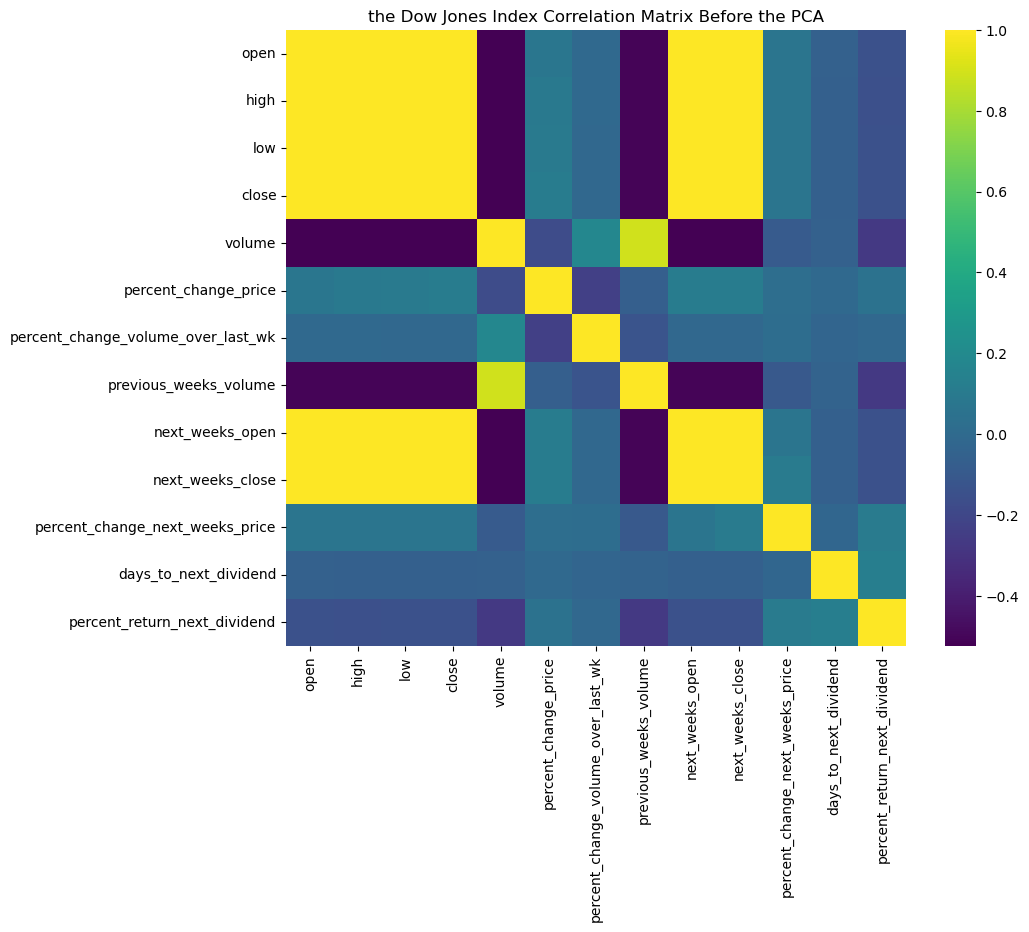

In [17]:
# CRITERIA BETWEEN TASKS ASSOCIATED AND NECESSARY VISUALIZATIONS

# is there a justification for PCA - does the correlation exist?

plt.figure(figsize=(10, 8))
sns.heatmap(X.corr(), cmap="viridis")

plt.title("Dow Jones Correlation Matrix Before PCA")

plt.savefig("dow_jones_correlation_matrix.png", bbox_inches="tight")
plt.show()

In [18]:
# COMMENTARY ON THE DJI HEATMAP
# the heatmap reveals strong positive correlations among price-related variables (open, high, low, close, and next week prices); 
# this indicates substantial redundancy in the dataset, volume variables also display notable correlation because many variables move together… 
# dimensionality reduction using PCA is a smart thing to do (PCA can capture the shared variance in fewer components while removing multicollinearity).

In [26]:
# CRITERIA 3 - TASKS ASSOCIATED w/ PCA

# (viii) Scaling

# from sklearn.preprocessing import StandardScaler (FROM CRITERIA 2 - "LIBRARY USED")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Confirming the Scale

X_scaled.mean(axis=0)[:5]
X_scaled.std(axis=0)[:5]

array([1., 1., 1., 1., 1.])

In [23]:
# CRITERIA 3 - TASKS ASSOCIATED w/ PCA

# verifying the Scaling -  Means & Std. Dev

print("First 5 Means:", X_scaled.mean(axis=0)[:5])
print("First 5 Standard Deviations:", X_scaled.std(axis=0)[:5])

First 5 Means: [-9.86864911e-17 -1.97372982e-16 -3.65140017e-16  9.86864911e-18
 -3.94745964e-17]
First 5 Standard Deviations: [1. 1. 1. 1. 1.]


In [24]:
# COMMENTARY ON MEANS & STD. DEVS

# After applying StandardScaler, the feature means are approximately zero and the standard deviations are approximately one. 
# And this confirms successful standardization, ensuring that no single variable dominates the PCA due to scale differences.

In [30]:
# CRITERIA 3 - TASKS ASSOCIATED w/ PCA

# the Fitting of the PCA

# from sklearn.decomposition import PCA (FROM CRITERIA 2 - "LIBRARY USED")

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# ... then

explained_variance = pca.explained_variance_ratio_
explained_variance

array([5.15394141e-01, 1.29420928e-01, 9.60004601e-02, 7.86750311e-02,
       7.06770897e-02, 5.87856568e-02, 4.62591861e-02, 4.63516092e-03,
       6.90166746e-05, 4.12212418e-05, 2.22155833e-05, 1.47787867e-05,
       5.11484886e-06])

In [31]:
# CRITERIA 3 - TASKS ASSOCIATED w/ PCA

# How much Total Variance is explained (if we keep the first k components)

# import numpy as np (FROM CRITERIA 2 - "LIBRARY USED")

cumulative_variance = np.cumsum(explained_variance)
cumulative_variance

array([0.51539414, 0.64481507, 0.74081553, 0.81949056, 0.89016765,
       0.94895331, 0.99521249, 0.99984765, 0.99991667, 0.99995789,
       0.99998011, 0.99999489, 1.        ])

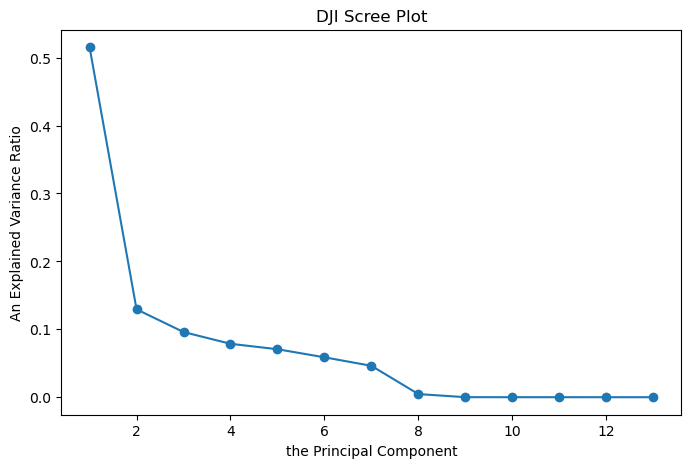

In [33]:
# CRITERIA 4 - NECESSARY VISUALIZATIONS/GRAPHS

# SCREE-PLOT

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(explained_variance)+1), explained_variance, marker='o')

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Dow Jones Scree Plot")

plt.savefig("pca_scree_plot.png", bbox_inches="tight")
plt.show()

In [35]:
# COMMENTARY ON SCREE-PLOT

# Scree PLOT portrays a very sharp drop from PC1 to PC2; after PC1 (~51%), variance decreases gradually… 
# the curve flattens significantly after around PC6–PC7, (components 8 onward contribute almost nothing). 
# the “elbow” pattern suggests most meaningful variance is captured within the first 5 to 6 components… 
# 'remaining components i.e. PC8 through PC12 (and beyond) add very little “explanatory power" (if any).

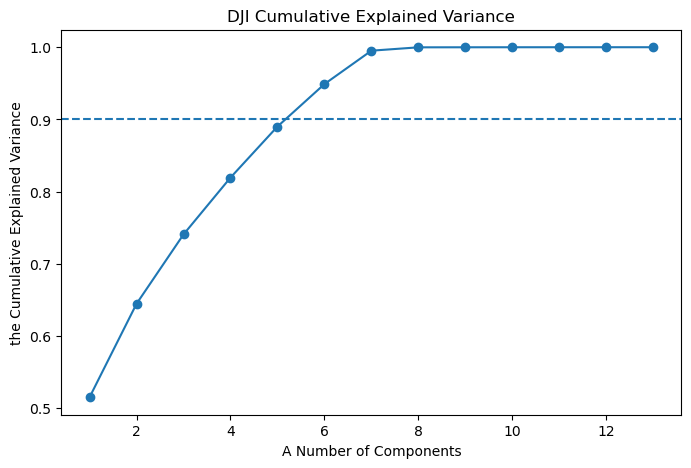

In [34]:
# CRITERIA 4 - NECESSARY VISUALIZATIONS/GRAPHS

# CUMULATIVE VARIANCE PLOT

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, marker='o')

plt.axhline(0.90, linestyle='--')

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Dow Jones Cumulative Explained Variance")

plt.savefig("pca_cumulative_variance.png", bbox_inches="tight")
plt.show()

In [36]:
# COMMENTARY ON CUMULATIVE VARIANCE PLOT

# From Cumulative Explained Variance PLOT, we gather that 90% threshold line intersects between 5 and 6 components.
# 4 components ≈ 82%
# 5 components ≈ 89%
# 6 components ≈ 95%
# WHICH MEANS: keeping 6 components captures about 95% of total variance 
# Simply put – from 13 variables we can reduce to only 6 components, that’s more than 50% dimensionality reduction.


In [37]:
# CRITERIA 4 - NECESSARY VISUALIZATIONS/GRAPHS

# Selecting # of Components - Formalizing the Selection

pca_final = PCA(n_components=6)
X_pca_final = pca_final.fit_transform(X_scaled)

X_pca_final.shape

(720, 6)

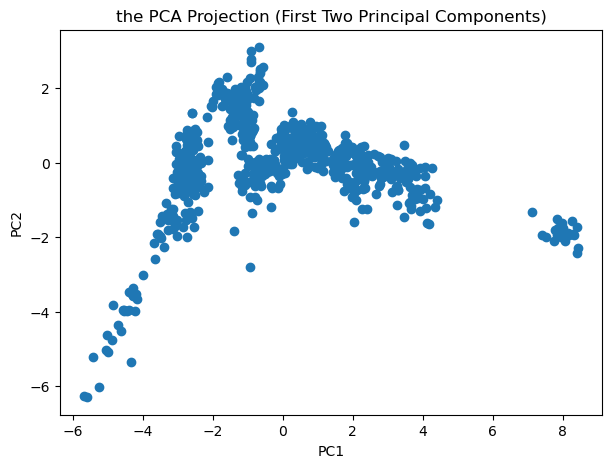

In [38]:
# CRITERIA 4 - NECESSARY VISUALIZATIONS/GRAPHS

# A 2D Projection using the first 2 components

plt.figure(figsize=(7, 5))
plt.scatter(X_pca_final[:, 0], X_pca_final[:, 1])

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection (First Two Principal Components)")

plt.savefig("pca_scatter_plot.png", bbox_inches="tight")
plt.show()

In [39]:
# COMMENTARY ON THE PCA 2d GRAPH PROJECTION

# PCA Projection shows that the first two principal components capture approximately 64% of the total variance; 
# the spread along PC1 suggests a dominant underlying market factor influencing multiple financial variables... 
# ... while PC2 captures secondary variation that differentiates observations beyond overall price movement, 
# the distribution appears continuous rather than forming discrete clusters, 
# to which I would cautiously say ought to be somewhat consistent with financial activity time-series behavior.